# Import Library

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import math 

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
from skorch import NeuralNetClassifier
from skorch.helper import predefined_split
from skorch.callbacks import EpochScoring
from IPython.display import display
import torch
print(torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SAVE_DIR = "learning_curves"
os.makedirs(SAVE_DIR, exist_ok=True)

from sklearn.model_selection import cross_val_score, StratifiedKFold

NumPy: 2.5.1
Pandas: 3.0.5
2.13.0+cu132
Device: cuda


# Load Dataset

In [16]:
data = pd.read_csv(
    "gsar_a_2521295_sm1572.csv",
    sep=";",
    skiprows=1,
    encoding="utf-8-sig"
)

data = data.dropna(subset=["SMILES", "label"]).reset_index(drop=True)
data["label"] = data["label"].astype(int)

print(data.shape)
data[["compound ID", "SMILES", "label"]].head()

(846, 8)


,compound ID,SMILES,label
0,A001,FC1(F)CN(c2c(C(F)(F)F)cnc3[nH]c(C4=CCNC4)cc23)C1,1
1,A002,CC(C)[C@@H](NC(=O)c1cc(-c2cnn3cc(-c4ccc(OCCN5C...,1
2,A003,O=C(NCC(F)(F)F)c1cc(-c2cnc3[nH]c(C4=CCCNC4)cc3...,1
3,A004,CN1CC=C(c2cc3cc(-c4csc(C(=O)NCC(F)(F)F)c4)cnc3...,1
4,A005,O=C(NCC(F)(F)F)c1cc(-c2cnc3[nH]c(C4=CCNCC4)cc3...,1


# Tokenisasi SMILES


In [17]:
X_smiles = data["SMILES"].values

charset = set("".join(list(X_smiles)) + "!E")
char_to_int = dict((c, i) for i, c in enumerate(charset))
int_to_char = dict((i, c) for i, c in enumerate(charset))

embed = max([len(smile) for smile in X_smiles]) + 5
vocab_size = len(charset)

print("Jumlah karakter unik (vocab_size):", vocab_size)
print("Panjang embedding (embed):", embed)
print(str(charset))

Jumlah karakter unik (vocab_size): 34
Panjang embedding (embed): 102
{'5', 'F', '/', 'P', ')', '#', '!', 'r', 'n', 'o', 'H', '@', '[', '4', '(', '-', 'I', 'c', ']', 's', 'S', '+', '=', '2', '1', '\\', 'E', '6', '3', 'C', 'O', 'B', 'l', 'N'}


In [18]:
char_to_int

{'5': 0,
 'F': 1,
 '/': 2,
 'P': 3,
 ')': 4,
 '#': 5,
 '!': 6,
 'r': 7,
 'n': 8,
 'o': 9,
 'H': 10,
 '@': 11,
 '[': 12,
 '4': 13,
 '(': 14,
 '-': 15,
 'I': 16,
 'c': 17,
 ']': 18,
 's': 19,
 'S': 20,
 '+': 21,
 '=': 22,
 '2': 23,
 '1': 24,
 '\\': 25,
 'E': 26,
 '6': 27,
 '3': 28,
 'C': 29,
 'O': 30,
 'B': 31,
 'l': 32,
 'N': 33}

# Fungsi Vectorize

In [19]:
def vectorize(smiles, charset, char_to_int, embed):
    one_hot = np.zeros((smiles.shape[0], embed, len(charset)), dtype=np.int8)
    for i, smile in enumerate(smiles):
        one_hot[i, 0, char_to_int["!"]] = 1
        for j, c in enumerate(smile):
            if c in char_to_int:
                one_hot[i, j + 1, char_to_int[c]] = 1
        one_hot[i, len(smile) + 1:, char_to_int["E"]] = 1
    return one_hot[:, 0:-1, :]

X_onehot = vectorize(X_smiles, charset, char_to_int, embed)
X_encoded = np.argmax(X_onehot, axis=2)

# Visual Hasil Encoding SMILES

In [20]:
print("vocab_size:", vocab_size, "| embed:", embed)
print("X_onehot shape :", X_onehot.shape)
print("X_encoded shape:", X_encoded.shape)

idx = 0

print("\nSMILES asli:", X_smiles[idx])
print()
print("One-hot encoding, 10 posisi pertama:")
print(X_onehot[idx][:10])

print("Integer-encoded, 20 posisi pertama:")
print(X_encoded[idx][:20])

decoded = "".join([int_to_char[i] for i in X_encoded[idx]])
print("Hasil decode balik:", decoded)

vocab_size: 34 | embed: 102
X_onehot shape : (846, 101, 34)
X_encoded shape: (846, 101)

SMILES asli: FC1(F)CN(c2c(C(F)(F)F)cnc3[nH]c(C4=CCNC4)cc23)C1

One-hot encoding, 10 posisi pertama:
[[0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
Integer-encoded, 20 posisi pertama:
[ 6  1 29 24 14  1  4 29 33 14 17 23 17 14 29 14  1  4 14  1]
Ha

# Penggabungan Hasil Encoding SMILES dengan Label

In [21]:
y = data["label"].values

print("X_encoded shape:", X_encoded.shape)
print("y shape         :", y.shape)

assert X_encoded.shape[0] == y.shape[0], "Jumlah baris SMILES dan label tidak sinkron!"

X_encoded shape: (846, 101)
y shape         : (846,)


# Split Train/Test

In [22]:
X = X_encoded
y_arr = y.reshape(-1, 1) if y.ndim == 1 else y

X_train, X_test, Y_train, Y_test = train_test_split(
    X, y_arr,
    test_size=0.3,
    random_state=42,
    stratify=y_arr
)

print("Training pool (untuk CV):", X_train.shape)
print("Holdout test (dikunci)  :", X_test.shape)

Training pool (untuk CV): (592, 101)
Holdout test (dikunci)  : (254, 101)


# Siapkan Data untuk Cross-Validation

In [23]:
X_cv = X_train.astype(np.int64)
Y_cv = Y_train.flatten().astype(np.int64) if Y_train.ndim > 1 else Y_train.astype(np.int64)

X_test_int = X_test.astype(np.int64)
Y_test_int = Y_test.flatten().astype(np.int64) if Y_test.ndim > 1 else Y_test.astype(np.int64)

print("Data untuk Cross-Validation:", X_cv.shape)
print("Holdout Test (dikunci)     :", X_test_int.shape)

Data untuk Cross-Validation: (592, 101)
Holdout Test (dikunci)     : (254, 101)


# Pembentukan model Baseline

In [24]:
class LSTMBaselineSkorch(nn.Module):
    def __init__(self, vocab_size, embedding_dim=50, units_list=[64]):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm_layers = nn.ModuleList()
        input_size = embedding_dim
        for units in units_list:
            self.lstm_layers.append(nn.LSTM(input_size=input_size, hidden_size=units, batch_first=True))
            input_size = units
        self.output_layer = nn.Linear(units_list[-1], 2)

    def forward(self, x):
        out = self.embedding(x)
        for lstm in self.lstm_layers:
            out, _ = lstm(out)
        out = out[:, -1, :]
        return self.output_layer(out)


def build_skorch_net_with_history(units_list, X_val, Y_val, vocab_size, embedding_dim=50,
                                   epochs=50, lr=0.001, batch_size=32, device=device):
    val_dataset = TensorDataset(
        torch.tensor(X_val, dtype=torch.long),
        torch.tensor(Y_val, dtype=torch.long)
    )

    return NeuralNetClassifier(
        module=LSTMBaselineSkorch,
        module__vocab_size=vocab_size,
        module__embedding_dim=embedding_dim,
        module__units_list=units_list,
        max_epochs=epochs,
        lr=lr,
        optimizer=torch.optim.Adam,
        criterion=nn.CrossEntropyLoss,
        batch_size=batch_size,
        device=device,
        train_split=predefined_split(val_dataset),
        callbacks=[
            ("train_acc", EpochScoring(scoring="accuracy", on_train=True, name="train_acc", lower_is_better=False)),
        ],
        verbose=0
    )


def compute_confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP, TN, FP, FN


def plot_confusion_matrix_image(TP, TN, FP, FN, model_name="", dataset_name=""):
    cm = np.array([[TP, FN],
                   [FP, TN]])

    fig, ax = plt.subplots(figsize=(5, 4.5))
    im = ax.imshow(cm, cmap="Blues")

    labels = ["Aktif (1)", "Inaktif (0)"]
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Kelas Prediksi")
    ax.set_ylabel("Kelas Aktual")
    ax.set_title(f"Confusion Matrix - {model_name} ({dataset_name})")

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black",
                     fontsize=14, fontweight="bold")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


def plot_avg_learning_curve(histories, model_name, save_dir=SAVE_DIR):
    avg_train_loss = np.mean([h["loss"] for h in histories], axis=0)
    avg_val_loss   = np.mean([h["val_loss"] for h in histories], axis=0)
    avg_train_acc  = np.mean([h["accuracy"] for h in histories], axis=0)
    avg_val_acc    = np.mean([h["val_accuracy"] for h in histories], axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(avg_train_loss, label="Training Loss")
    axes[0].plot(avg_val_loss, label="Validation Loss")
    axes[0].set_title(f"Loss Curve - {model_name}")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(avg_train_acc, label="Training Accuracy")
    axes[1].plot(avg_val_acc, label="Validation Accuracy")
    axes[1].set_title(f"Accuracy Curve - {model_name}")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    save_path = os.path.join(save_dir, f"learning_curve_CV_{model_name.replace(' ', '_')}.png")
    plt.savefig(save_path, dpi=150)
    print(f"Learning curve disimpan di: {save_path}")
    plt.show()

# Konfigurasi Baseline

In [25]:
baseline_configs = {
    "Baseline 1": [64],
    "Baseline 2": [64, 128],
    "Baseline 3": [64, 128, 256],
}

config_table = []

for name, units_list in baseline_configs.items():
    config_table.append({
        "Konfigurasi": name,
        "Jumlah Layer LSTM": len(units_list),
        "Node per Lapisan": str(tuple(units_list)),
        "Lapisan Output": "Dense 1 neuron, aktivasi Sigmoid",
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "Optimizer": "Adam",
        "Epoch": 50,
    })

config_df = pd.DataFrame(config_table).set_index("Konfigurasi")
display(config_df)

,Jumlah Layer LSTM,Node per Lapisan,Lapisan Output,Learning Rate,Batch Size,Optimizer,Epoch
Konfigurasi,,,,,,,
Baseline 1,1,"(64,)","Dense 1 neuron, aktivasi Sigmoid",0.001,32,Adam,50
Baseline 2,2,"(64, 128)","Dense 1 neuron, aktivasi Sigmoid",0.001,32,Adam,50
Baseline 3,3,"(64, 128, 256)","Dense 1 neuron, aktivasi Sigmoid",0.001,32,Adam,50


# Cross-Validation (cv=5) dengan Learning Curve per Fold

In [26]:
def cross_val_with_history(units_list, X_cv, Y_cv, k=5, epochs=50, lr=0.001, batch_size=32, model_name=""):
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    fold_scores = []
    fold_histories = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_cv, Y_cv)):
        print(f"--- {model_name} | Fold {fold_idx + 1}/{k} ---")

        X_tr, X_val = X_cv[train_idx], X_cv[val_idx]
        Y_tr, Y_val = Y_cv[train_idx], Y_cv[val_idx]

        net = build_skorch_net_with_history(
            units_list, X_val, Y_val,
            vocab_size=vocab_size, epochs=epochs, lr=lr, batch_size=batch_size
        )
        net.fit(X_tr, Y_tr)

        history = {
            "loss": [row["train_loss"] for row in net.history],
            "val_loss": [row["valid_loss"] for row in net.history],
            "accuracy": [row["train_acc"] for row in net.history],
            "val_accuracy": [row["valid_acc"] for row in net.history],
        }
        fold_histories.append(history)

        val_acc = history["val_accuracy"][-1]
        fold_scores.append(val_acc)
        print(f"Fold {fold_idx + 1} val_accuracy: {val_acc:.4f}")

    return np.array(fold_scores), fold_histories

# Jalankan Cross Val

In [27]:
cv_results = {}
cv_histories = {}

for name, units_list in baseline_configs.items():
    print("="*60)
    print(f"CROSS-VALIDATION (cv=5) | {name} | LSTM layers: {units_list}")
    print("="*60)

    scores, histories = cross_val_with_history(
        units_list, X_cv, Y_cv,
        k=5, epochs=50, lr=0.001, batch_size=32, model_name=name
    )
    cv_results[name] = scores
    cv_histories[name] = histories

    print(f"Rata-rata Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

CROSS-VALIDATION (cv=5) | Baseline 1 | LSTM layers: [64]
--- Baseline 1 | Fold 1/5 ---
Fold 1 val_accuracy: 0.8824
--- Baseline 1 | Fold 2/5 ---
Fold 2 val_accuracy: 0.8403
--- Baseline 1 | Fold 3/5 ---
Fold 3 val_accuracy: 0.8983
--- Baseline 1 | Fold 4/5 ---
Fold 4 val_accuracy: 0.8305
--- Baseline 1 | Fold 5/5 ---
Fold 5 val_accuracy: 0.8729
Rata-rata Accuracy: 0.8649 (+/- 0.0256)
CROSS-VALIDATION (cv=5) | Baseline 2 | LSTM layers: [64, 128]
--- Baseline 2 | Fold 1/5 ---
Fold 1 val_accuracy: 0.8319
--- Baseline 2 | Fold 2/5 ---
Fold 2 val_accuracy: 0.9076
--- Baseline 2 | Fold 3/5 ---
Fold 3 val_accuracy: 0.9068
--- Baseline 2 | Fold 4/5 ---
Fold 4 val_accuracy: 0.8559
--- Baseline 2 | Fold 5/5 ---
Fold 5 val_accuracy: 0.9153
Rata-rata Accuracy: 0.8835 (+/- 0.0333)
CROSS-VALIDATION (cv=5) | Baseline 3 | LSTM layers: [64, 128, 256]
--- Baseline 3 | Fold 1/5 ---
Fold 1 val_accuracy: 0.8739
--- Baseline 3 | Fold 2/5 ---
Fold 2 val_accuracy: 0.8655
--- Baseline 3 | Fold 3/5 ---
Fold 3 v

# Learning Curve

Learning curve disimpan di: learning_curves\learning_curve_CV_Baseline_1.png


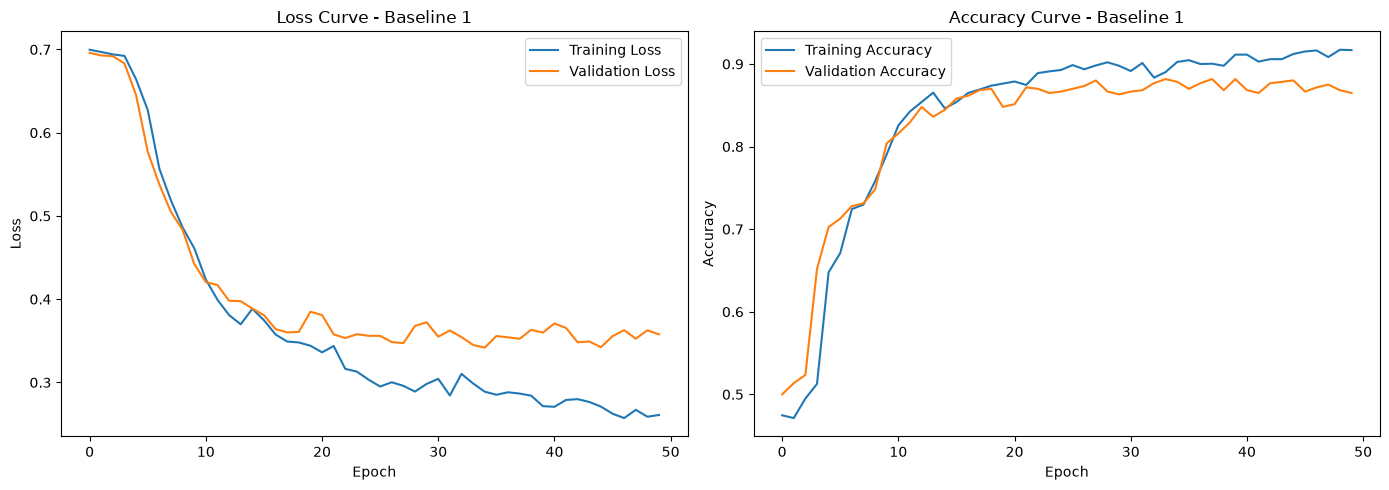

Learning curve disimpan di: learning_curves\learning_curve_CV_Baseline_2.png


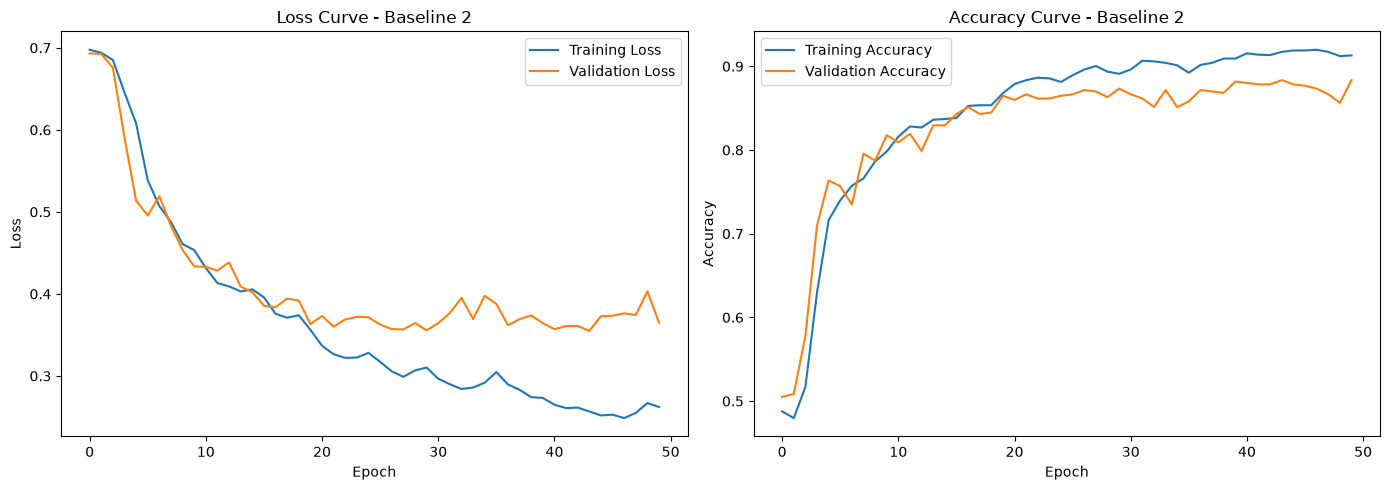

Learning curve disimpan di: learning_curves\learning_curve_CV_Baseline_3.png


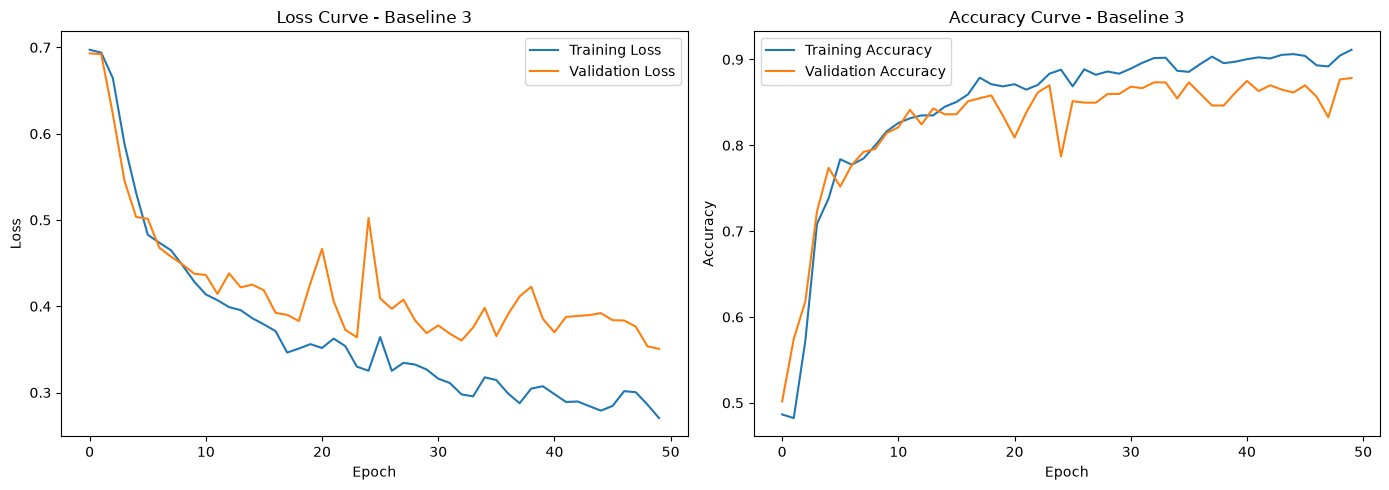

In [28]:
for name, histories in cv_histories.items():
    plot_avg_learning_curve(histories, model_name=name)

# Ringkasan Hasil Cross-Validation ke Satu DataFrame

In [29]:
summary_rows = []

for name, units_list in baseline_configs.items():
    scores = cv_results[name]          # array accuracy tiap fold (5 nilai)
    histories = cv_histories[name]      # list of dict, satu per fold

    # Rata-rata learning curve dari 5 fold, ambil nilai epoch TERAKHIR
    avg_train_loss = np.mean([h["loss"][-1] for h in histories])
    avg_val_loss   = np.mean([h["val_loss"][-1] for h in histories])
    avg_train_acc  = np.mean([h["accuracy"][-1] for h in histories])
    avg_val_acc    = np.mean([h["val_accuracy"][-1] for h in histories])

    row = {
        "Konfigurasi": name,
        "Jumlah Layer LSTM": len(units_list),
        "Node per Lapisan": str(tuple(units_list)),
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "Epoch": 50,
    }

    # Accuracy tiap fold (Fold 1 - Fold 5)
    for i, score in enumerate(scores):
        row[f"Fold {i+1} Accuracy"] = score

    row["Accuracy Mean"] = scores.mean()
    row["Accuracy Std"]  = scores.std()

    # Nilai akhir learning curve (rata-rata dari 5 fold, epoch terakhir)
    row["Avg Train Loss (epoch akhir)"] = avg_train_loss
    row["Avg Val Loss (epoch akhir)"]   = avg_val_loss
    row["Avg Train Acc (epoch akhir)"]  = avg_train_acc
    row["Avg Val Acc (epoch akhir)"]    = avg_val_acc

    summary_rows.append(row)

full_summary_df = pd.DataFrame(summary_rows).set_index("Konfigurasi")
display(full_summary_df)

,Jumlah Layer LSTM,Node per Lapisan,Learning Rate,Batch Size,Epoch,Fold 1 Accuracy,Fold 2 Accuracy,Fold 3 Accuracy,Fold 4 Accuracy,Fold 5 Accuracy,Accuracy Mean,Accuracy Std,Avg Train Loss (epoch akhir),Avg Val Loss (epoch akhir),Avg Train Acc (epoch akhir),Avg Val Acc (epoch akhir)
Konfigurasi,,,,,,,,,,,,,,,,
Baseline 1,1,"(64,)",0.001,32,50,0.882353,0.840336,0.898305,0.830508,0.872881,0.864877,0.025575,0.260865,0.357705,0.916807,0.864877
Baseline 2,2,"(64, 128)",0.001,32,50,0.831933,0.907563,0.906780,0.855932,0.915254,0.883492,0.033312,0.262087,0.364893,0.913015,0.883492
Baseline 3,3,"(64, 128, 256)",0.001,32,50,0.873950,0.865546,0.906780,0.855932,0.889831,0.878408,0.018033,0.270366,0.350604,0.911326,0.878408


# Evaluasi Final Baseline (Train & Test)

TRAINING FINAL | Baseline 1 | units_list: [64]


  epoch    train_loss     dur
-------  ------------  ------
      1        0.6982  0.0810
      2        0.6919  0.0664
      3        0.6859  0.0602
      4        0.6343  0.0719
      5        0.5354  0.0875
      6        0.4737  0.0654
      7        0.4504  0.0609
      8        0.4299  0.0620
      9        0.4135  0.0736
     10        0.3894  0.0611
     11        0.3789  0.0560
     12        0.3632  0.0568
     13        0.3582  0.0579
     14        0.3358  0.0937
     15        0.3476  0.0794
     16        0.3227  0.0635
     17        0.3174  0.0586
     18        0.3147  0.0732
     19        0.3177  0.0715
     20        0.3035  0.0648
     21        0.3296  0.0612
     22        0.3159  0.0643
     23        0.4153  0.0734
     24        0.3406  0.0710
     25        0.3128  0.0614
     26        0.2999  0.0637
     27        0.2985  0.0600
     28        0.2975  0.0787
     29        0.2881  0.0753
     30        0.2884  0.0717
     31        0.2922  0.0663
     32   

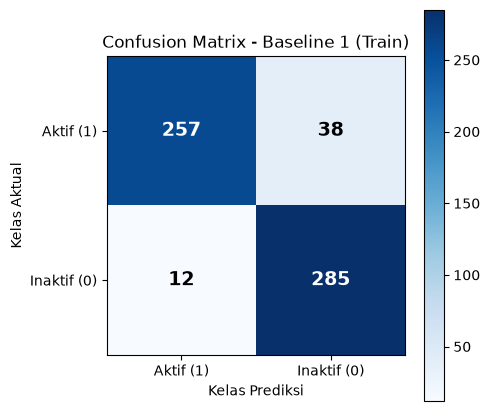

Accuracy  : 0.9155
Recall    : 0.8712
Precision : 0.9554
F1-Score  : 0.9113
>>> Evaluasi Baseline 1 pada Holdout Test <<<


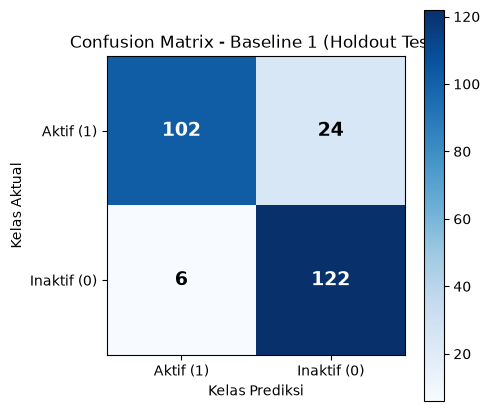

Accuracy  : 0.8819
Recall    : 0.8095
Precision : 0.9444
F1-Score  : 0.8718
TRAINING FINAL | Baseline 2 | units_list: [64, 128]
  epoch    train_loss     dur
-------  ------------  ------
      1        0.6959  0.1515
      2        0.6921  0.1206
      3        0.6023  0.1093
      4        0.5128  0.0985
      5        0.4655  0.0918
      6        0.4566  0.0857
      7        0.4354  0.0842
      8        0.4271  0.0856
      9        0.3922  0.0830
     10        0.3668  0.0838
     11        0.3703  0.0948
     12        0.3453  0.0876
     13        0.3332  0.0827
     14        0.3272  0.0844
     15        0.3319  0.0836
     16        0.3364  0.0839
     17        0.2939  0.0807
     18        0.2906  0.0815
     19        0.2938  0.0909
     20        0.3054  0.0825
     21        0.2983  0.0819
     22        0.3377  0.0806
     23        0.3504  0.0814
     24        0.3029  0.0794
     25        0.2807  0.0896
     26        0.2836  0.0846
     27        0.2838  0.0868
  

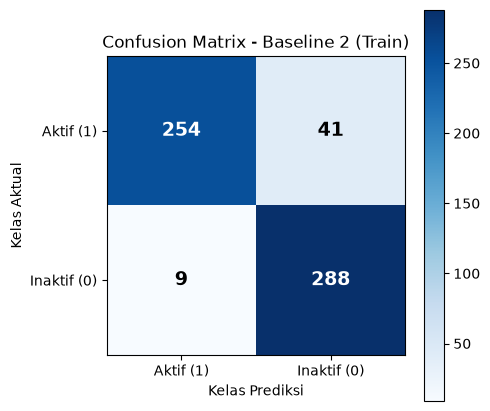

Accuracy  : 0.9155
Recall    : 0.8610
Precision : 0.9658
F1-Score  : 0.9104
>>> Evaluasi Baseline 2 pada Holdout Test <<<


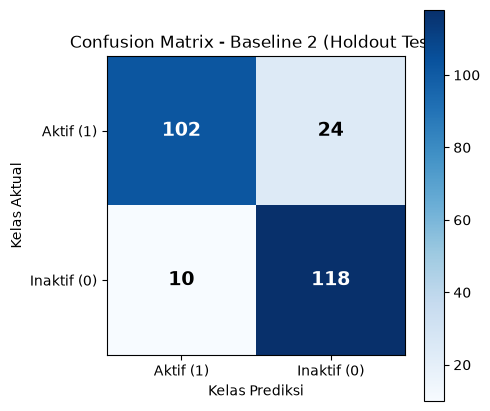

Accuracy  : 0.8661
Recall    : 0.8095
Precision : 0.9107
F1-Score  : 0.8571
TRAINING FINAL | Baseline 3 | units_list: [64, 128, 256]
  epoch    train_loss     dur
-------  ------------  ------
      1        0.6956  0.2372
      2        0.6824  0.2130
      3        0.5415  0.2143
      4        0.5065  0.2096
      5        0.4545  0.2193
      6        0.4379  0.2373
      7        0.4281  0.2452
      8        0.4254  0.2599
      9        0.4184  0.2123
     10        0.4070  0.2166
     11        0.4019  0.2010
     12        0.3641  0.2095
     13        0.3816  0.2132
     14        0.3682  0.2093
     15        0.3476  0.2113
     16        0.3303  0.2757
     17        0.3189  0.2732
     18        0.3772  0.2456
     19        0.3392  0.2403
     20        0.3255  0.2485
     21        0.4199  0.2486
     22        0.3956  0.2434
     23        0.3472  0.2862
     24        0.3180  0.2332
     25        0.3034  0.2249
     26        0.2997  0.2349
     27        0.3029  0.25

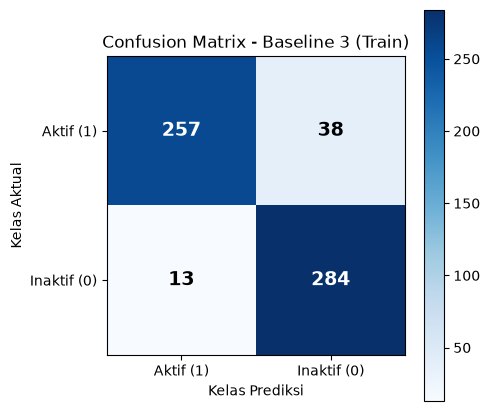

Accuracy  : 0.9139
Recall    : 0.8712
Precision : 0.9519
F1-Score  : 0.9097
>>> Evaluasi Baseline 3 pada Holdout Test <<<


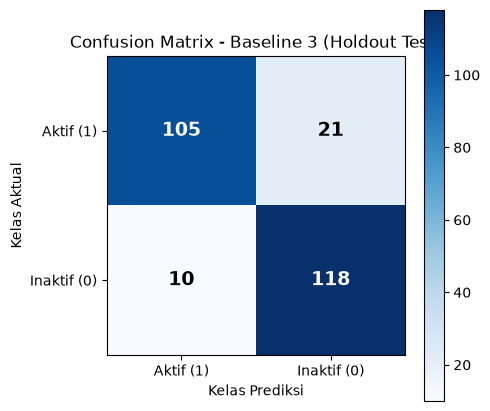

Accuracy  : 0.8780
Recall    : 0.8333
Precision : 0.9130
F1-Score  : 0.8714


In [30]:
def compute_metrics(TP, TN, FP, FN, eps=1e-10):
    accuracy  = (TP + TN) / (TP + TN + FP + FN + eps)
    recall    = TP / (TP + FN + eps)
    precision = TP / (TP + FP + eps)
    f1_score  = 2 * (precision * recall) / (precision + recall + eps)
    return {"accuracy": accuracy, "recall": recall, "precision": precision, "f1_score": f1_score}


final_baseline_nets = {}
baseline_eval_results = {}

for name, units_list in baseline_configs.items():
    print("="*60)
    print(f"TRAINING FINAL | {name} | units_list: {units_list}")
    print("="*60)

    net = NeuralNetClassifier(
        module=LSTMBaselineSkorch,
        module__vocab_size=vocab_size,
        module__embedding_dim=50,
        module__units_list=units_list,
        max_epochs=50,
        lr=0.001,
        optimizer=torch.optim.Adam,
        criterion=nn.CrossEntropyLoss,
        batch_size=32,
        device=device,
        train_split=None,
        verbose=1
    )
    net.fit(X_cv, Y_cv)
    final_baseline_nets[name] = net

    # Evaluasi ke Train
    y_pred_train = net.predict(X_cv)
    TP_tr, TN_tr, FP_tr, FN_tr = compute_confusion_matrix(Y_cv, y_pred_train)
    metrics_train = compute_metrics(TP_tr, TN_tr, FP_tr, FN_tr)

    print(f">>> Evaluasi {name} pada Train <<<")
    plot_confusion_matrix_image(TP_tr, TN_tr, FP_tr, FN_tr, model_name=name, dataset_name="Train")
    print(f"Accuracy  : {metrics_train['accuracy']:.4f}")
    print(f"Recall    : {metrics_train['recall']:.4f}")
    print(f"Precision : {metrics_train['precision']:.4f}")
    print(f"F1-Score  : {metrics_train['f1_score']:.4f}")

    # Evaluasi ke Test
    y_pred_test = net.predict(X_test_int)
    TP_te, TN_te, FP_te, FN_te = compute_confusion_matrix(Y_test_int, y_pred_test)
    metrics_test = compute_metrics(TP_te, TN_te, FP_te, FN_te)

    print(f">>> Evaluasi {name} pada Holdout Test <<<")
    plot_confusion_matrix_image(TP_te, TN_te, FP_te, FN_te, model_name=name, dataset_name="Holdout Test")
    print(f"Accuracy  : {metrics_test['accuracy']:.4f}")
    print(f"Recall    : {metrics_test['recall']:.4f}")
    print(f"Precision : {metrics_test['precision']:.4f}")
    print(f"F1-Score  : {metrics_test['f1_score']:.4f}")

    baseline_eval_results[name] = {"train": metrics_train, "test": metrics_test}

# Parameter Monarch Butterfly Optimization (MBO)

In [31]:
mbo_params_table = pd.DataFrame([
    {"Parameter": "Jumlah Populasi (NP)", "Nilai": 50},
    {"Parameter": "Rasio Migrasi (p)", "Nilai": "[0.1, 0.25, 0.5]"},
    {"Parameter": "Langkah Maksimum (Smax)", "Nilai": 1.0},
    {"Parameter": "Faktor Skala (alpha)", "Nilai": "alpha_t = Smax / t^2 (Persamaan 11)"},
    {"Parameter": "Iterasi Maksimum", "Nilai": 50},
]).set_index("Parameter")

display(mbo_params_table)

,Nilai
Parameter,
Jumlah Populasi (NP),50
Rasio Migrasi (p),"[0.1, 0.25, 0.5]"
Langkah Maksimum (Smax),1.0
Faktor Skala (alpha),alpha_t = Smax / t^2 (Persamaan 11)
Iterasi Maksimum,50


# Skema optimasi MBO

In [32]:
mbo_schemes = {
    "MBO 1": {"p": 0.1},
    "MBO 2": {"p": 0.25},
    "MBO 3": {"p": 0.5},
}

mbo_schemes_table = pd.DataFrame([
    {"Skema": name, "Rasio Migrasi (p)": cfg["p"]}
    for name, cfg in mbo_schemes.items()
]).set_index("Skema")

display(mbo_schemes_table)

,Rasio Migrasi (p)
Skema,
MBO 1,0.10
MBO 2,0.25
MBO 3,0.50


# Definisi ruang pencarian Hyperparameter LSTM

In [33]:
# Catatan asumsi: MBO mengoptimasi jumlah node tiap lapisan LSTM (3 lapisan, mengikuti
# arsitektur baseline paling kompleks) dan learning rate. Batas (bounds) ditentukan
# secara wajar berdasarkan konfigurasi baseline pada Tabel 3.

DIM = 4  # jumlah variabel keputusan: units_layer1, units_layer2, units_layer3, log10(lr)

BOUNDS = np.array([
    [16, 128],     # units layer 1
    [32, 256],     # units layer 2
    [64, 512],     # units layer 3
    [-4, -2],       # log10(learning rate), lr antara 0.0001 - 0.01
])

def decode_solution(vector):
    """Ubah vektor kontinu MBO menjadi hyperparameter LSTM yang valid."""
    units1 = int(np.clip(round(vector[0]), BOUNDS[0, 0], BOUNDS[0, 1]))
    units2 = int(np.clip(round(vector[1]), BOUNDS[1, 0], BOUNDS[1, 1]))
    units3 = int(np.clip(round(vector[2]), BOUNDS[2, 0], BOUNDS[2, 1]))
    lr = 10 ** np.clip(vector[3], BOUNDS[3, 0], BOUNDS[3, 1])
    return {"units_list": [units1, units2, units3], "lr": lr}

# Fitness Function

In [34]:
def fitness_function(vector, X_cv, Y_cv, vocab_size, cv_folds=5, epochs=20, batch_size=32):
    """
    Fitness = rata-rata accuracy dari cross_val_score (k-fold CV).
    epochs sengaja lebih kecil (20) dibanding training final (50) untuk
    mempercepat proses pencarian MBO, karena tiap evaluasi fitness akan
    dipanggil ratusan-ribuan kali (NP x max_iter x jumlah skema).
    """
    config = decode_solution(vector)

    net = NeuralNetClassifier(
        module=LSTMBaselineSkorch,
        module__vocab_size=vocab_size,
        module__embedding_dim=50,
        module__units_list=config["units_list"],
        max_epochs=epochs,
        lr=config["lr"],
        optimizer=torch.optim.Adam,
        criterion=nn.CrossEntropyLoss,
        batch_size=batch_size,
        device=device,
        train_split=None,
        verbose=0
    )

    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

    try:
        scores = cross_val_score(net, X_cv, Y_cv, cv=skf, scoring="accuracy", n_jobs=1)
        return scores.mean()
    except Exception as e:
        print(f"Evaluasi gagal untuk konfigurasi {config}: {e}")
        return 0.0  # fitness terburuk kalau kombinasi hyperparameter gagal dilatih

# Implementasi Algoritma MBO

In [35]:
def initialize_population(NP, dim, bounds):
    population = np.zeros((NP, dim))
    for d in range(dim):
        population[:, d] = np.random.uniform(bounds[d, 0], bounds[d, 1], NP)
    return population


def migration_operator(subpop1, subpop2, p, dim):
    """Migration operator: individu subpop1 diperbarui berdasarkan subpop1 atau subpop2."""
    NP1 = len(subpop1)
    new_subpop1 = np.copy(subpop1)

    for i in range(NP1):
        for d in range(dim):
            r = np.random.uniform(0, 1) * 1.0  # dikali periode migrasi (asumsi = 1.0)
            if r <= p:
                r1 = np.random.randint(0, NP1)
                new_subpop1[i, d] = subpop1[r1, d]
            else:
                r2 = np.random.randint(0, len(subpop2))
                new_subpop1[i, d] = subpop2[r2, d]

    return new_subpop1


def butterfly_adjusting_operator(subpop2, best_solution, alpha_t, p, BAR, dim):
    """Butterfly adjusting operator: individu subpop2 diperbarui mendekati solusi terbaik."""
    NP2 = len(subpop2)
    new_subpop2 = np.copy(subpop2)

    for i in range(NP2):
        for d in range(dim):
            if np.random.uniform(0, 1) <= p:
                new_subpop2[i, d] = best_solution[d]
            else:
                r3 = np.random.randint(0, NP2)
                new_subpop2[i, d] = subpop2[r3, d]

                if np.random.uniform(0, 1) > BAR:
                    dx = levy_step(dim)
                    new_subpop2[i, d] += alpha_t * (dx[d] - 0.5)

    return new_subpop2


def levy_step(dim, beta=1.5):
    """Random walk berdasarkan Levy flight, dipakai di butterfly adjusting operator."""
    sigma = (math.gamma(1 + beta) * np.sin(np.pi * beta / 2) /
             (math.gamma((1 + beta) / 2) * beta * (2 ** ((beta - 1) / 2)))) ** (1 / beta)
    u = np.random.normal(0, sigma, dim)
    v = np.random.normal(0, 1, dim)
    step = u / (np.abs(v) ** (1 / beta))
    return step


def clip_to_bounds(population, bounds):
    for d in range(bounds.shape[0]):
        population[:, d] = np.clip(population[:, d], bounds[d, 0], bounds[d, 1])
    return population

# Fungsi utama MBO

In [36]:
def run_mbo(p, X_cv, Y_cv, vocab_size, NP=10, max_iter=10, Smax=1.0, BAR=5/12,
            dim=DIM, bounds=BOUNDS, cv_folds=5, fitness_epochs=20, scheme_name=""):

    NP1 = int(np.ceil(p * NP))
    NP2 = NP - NP1

    population = initialize_population(NP, dim, bounds)

    print(f"[{scheme_name}] Mengevaluasi populasi awal ({NP} individu)...")
    fitness = np.zeros(NP)
    for i, ind in enumerate(population):
        fitness[i] = fitness_function(ind, X_cv, Y_cv, vocab_size, cv_folds=cv_folds, epochs=fitness_epochs)
        print(f"[{scheme_name}] Individu {i+1}/{NP} dievaluasi - fitness: {fitness[i]:.4f}")

    best_idx = np.argmax(fitness)
    best_solution = population[best_idx].copy()
    best_fitness = fitness[best_idx]

    convergence_curve = [best_fitness]

    for t in range(1, max_iter + 1):
        alpha_t = Smax / (t ** 2)

        sorted_idx = np.argsort(-fitness)
        population = population[sorted_idx]
        fitness = fitness[sorted_idx]

        subpop1 = population[:NP1]
        subpop2 = population[NP1:]

        new_subpop1 = migration_operator(subpop1, subpop2, p, dim)
        new_subpop2 = butterfly_adjusting_operator(subpop2, best_solution, alpha_t, p, BAR, dim)

        new_population = np.vstack([new_subpop1, new_subpop2])
        new_population = clip_to_bounds(new_population, bounds)

        print(f"[{scheme_name}] Iterasi {t}/{max_iter} - mengevaluasi {NP} individu baru...")
        new_fitness = np.zeros(NP)
        for i, ind in enumerate(new_population):
            new_fitness[i] = fitness_function(ind, X_cv, Y_cv, vocab_size, cv_folds=cv_folds, epochs=fitness_epochs)
            print(f"[{scheme_name}] Iterasi {t} - Individu {i+1}/{NP} dievaluasi - fitness: {new_fitness[i]:.4f}")

        combined_population = np.vstack([population, new_population])
        combined_fitness = np.concatenate([fitness, new_fitness])

        best_indices = np.argsort(-combined_fitness)[:NP]
        population = combined_population[best_indices]
        fitness = combined_fitness[best_indices]

        if fitness[0] > best_fitness:
            best_fitness = fitness[0]
            best_solution = population[0].copy()

        convergence_curve.append(best_fitness)
        print(f"[{scheme_name}] Iterasi {t}/{max_iter} SELESAI - Best Fitness (Accuracy): {best_fitness:.4f}")

    return best_solution, best_fitness, convergence_curve

# Jalankan MBO untuk ketiga skema

In [ ]:
mbo_results = {}

for scheme_name, cfg in mbo_schemes.items():
    print("="*60)
    print(f"MENJALANKAN {scheme_name} | Rasio Migrasi (p) = {cfg['p']}")
    print("="*60)

    best_solution, best_fitness, convergence_curve = run_mbo(
        p=cfg["p"],
        X_cv=X_cv, Y_cv=Y_cv,
        vocab_size=vocab_size,
        NP=10,
        max_iter=10,
        Smax=1.0,
        cv_folds=5,
        fitness_epochs=20,
        scheme_name=scheme_name
    )

    mbo_results[scheme_name] = {
        "best_solution": best_solution,
        "best_fitness": best_fitness,
        "convergence_curve": convergence_curve,
        "best_config": decode_solution(best_solution),
    }

    print(f"\n{scheme_name} SELESAI | Best Accuracy (CV): {best_fitness:.4f}")
    print(f"Konfigurasi terbaik: {mbo_results[scheme_name]['best_config']}")

MENJALANKAN MBO 1 | Rasio Migrasi (p) = 0.1
[MBO 1] Mengevaluasi populasi awal (10 individu)...
[MBO 1] Individu 1/10 dievaluasi - fitness: 0.8278
[MBO 1] Individu 2/10 dievaluasi - fitness: 0.7956
[MBO 1] Individu 3/10 dievaluasi - fitness: 0.8378
[MBO 1] Individu 4/10 dievaluasi - fitness: 0.7770
[MBO 1] Individu 5/10 dievaluasi - fitness: 0.5723
[MBO 1] Individu 6/10 dievaluasi - fitness: 0.7939
[MBO 1] Individu 7/10 dievaluasi - fitness: 0.8447
[MBO 1] Individu 8/10 dievaluasi - fitness: 0.7721
[MBO 1] Individu 9/10 dievaluasi - fitness: 0.8159
[MBO 1] Individu 10/10 dievaluasi - fitness: 0.7905
[MBO 1] Iterasi 1/10 - mengevaluasi 10 individu baru...
[MBO 1] Iterasi 1 - Individu 1/10 dievaluasi - fitness: 0.7785
[MBO 1] Iterasi 1 - Individu 2/10 dievaluasi - fitness: 0.8514
[MBO 1] Iterasi 1 - Individu 3/10 dievaluasi - fitness: 0.7905
[MBO 1] Iterasi 1 - Individu 4/10 dievaluasi - fitness: 0.7804
[MBO 1] Iterasi 1 - Individu 5/10 dievaluasi - fitness: 0.7854
[MBO 1] Iterasi 1 - In

# Plot Kurva Konvergensi ketiga skema MBO

In [ ]:
plt.figure(figsize=(10, 6))

for scheme_name, result in mbo_results.items():
    plt.plot(result["convergence_curve"], label=scheme_name)

plt.title("Kurva Konvergensi MBO (Accuracy Terbaik per Iterasi)")
plt.xlabel("Iterasi")
plt.ylabel("Best Fitness (Accuracy)")
plt.legend()
plt.tight_layout()

save_path = os.path.join(SAVE_DIR, "mbo_convergence_curve.png")
plt.savefig(save_path, dpi=150)
print(f"Kurva konvergensi disimpan di: {save_path}")
plt.show()

# Ringkasan Hasil MBO

In [ ]:
mbo_summary_rows = []

for scheme_name, result in mbo_results.items():
    config = result["best_config"]
    mbo_summary_rows.append({
        "Skema": scheme_name,
        "Rasio Migrasi (p)": mbo_schemes[scheme_name]["p"],
        "Units Layer 1": config["units_list"][0],
        "Units Layer 2": config["units_list"][1],
        "Units Layer 3": config["units_list"][2],
        "Learning Rate": config["lr"],
        "Best Accuracy (CV)": result["best_fitness"],
    })

mbo_summary_df = pd.DataFrame(mbo_summary_rows).set_index("Skema")
display(mbo_summary_df)

# Train Skema MBO terbaik

In [ ]:
best_scheme_name = mbo_summary_df["Best Accuracy (CV)"].idxmax()
best_scheme_config = mbo_results[best_scheme_name]["best_config"]

print(f"Skema MBO terbaik: {best_scheme_name}")
print(f"Konfigurasi terbaik: {best_scheme_config}")

final_mbo_net = NeuralNetClassifier(
    module=LSTMBaselineSkorch,
    module__vocab_size=vocab_size,
    module__embedding_dim=50,
    module__units_list=best_scheme_config["units_list"],
    max_epochs=50,           # epoch penuh untuk model final, sesuai Tabel 4 (Iterasi Maksimum)
    lr=best_scheme_config["lr"],
    optimizer=torch.optim.Adam,
    criterion=nn.CrossEntropyLoss,
    batch_size=32,
    device=device,
    train_split=None,
    verbose=1
)

final_mbo_net.fit(X_cv, Y_cv)

 # Evaluasi 

In [ ]:
def compute_metrics(TP, TN, FP, FN, eps=1e-10):
    accuracy  = (TP + TN) / (TP + TN + FP + FN + eps)   # Persamaan 12
    recall    = TP / (TP + FN + eps)                     # Persamaan 13
    precision = TP / (TP + FP + eps)                     # Persamaan 14
    f1_score  = 2 * (precision * recall) / (precision + recall + eps)  # Persamaan 15
    return {"accuracy": accuracy, "recall": recall, "precision": precision, "f1_score": f1_score}

In [ ]:
y_pred_mbo = final_mbo_net.predict(X_test_int)

TP, TN, FP, FN = compute_confusion_matrix(Y_test_int, y_pred_mbo)
metrics_mbo = compute_metrics(TP, TN, FP, FN)

print(f">>> Evaluasi Model Hasil MBO ({best_scheme_name}) pada Holdout Test <<<")
plot_confusion_matrix_image(TP, TN, FP, FN, model_name=f"Model MBO ({best_scheme_name})", dataset_name="Holdout Test")

print(f"Accuracy  : {metrics_mbo['accuracy']:.4f}")
print(f"Recall    : {metrics_mbo['recall']:.4f}")
print(f"Precision : {metrics_mbo['precision']:.4f}")
print(f"F1-Score  : {metrics_mbo['f1_score']:.4f}")

# Bandingkan ketiga skema MBO dan baseline

In [ ]:
comparison_rows = []

# Tambahkan hasil ketiga skema MBO (evaluasi CV, bukan holdout test)
for scheme_name, result in mbo_results.items():
    comparison_rows.append({
        "Model": scheme_name,
        "Tipe": "MBO",
        "Accuracy (CV)": result["best_fitness"],
    })

# Tambahkan hasil model MBO terbaik pada holdout test
comparison_rows.append({
    "Model": f"{best_scheme_name} (Final - Holdout Test)",
    "Tipe": "MBO Final",
    "Accuracy (CV)": metrics_mbo["accuracy"],
})

comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
display(comparison_df)